# Getting price for reference items

I'm done entering all my receipts. Each expense is matched with a product, which is matched with a reference item. The reference item is the non-gluten-free product that we calculate the price difference with. 

Things we'll need for each reference item:
- Price
- Weight
- URL
- Screenshot (as proof)
- Time stamp of scrape

I usually look at Walmart.ca, not because I would buy from them, but because they will likely have the lowest price point on the generic reference product. 


### First lets get the updated list of reference

Prisma saves it to sqlite. I could use an API call like I did for the writes, but since I'm using only a single table I'll just grab it directly. 

In [149]:
%pip install -q pandas

Note: you may need to restart the kernel to use updated packages.


In [153]:
import sqlite3
import pandas as pd

# open sqlite ../receipts-app/prisma/dev.db
# grab ReferenceItem table
# throw it into a pandas data frame

# Connect to the SQLite database
conn = sqlite3.connect('../receipts-app/prisma/dev.db')

# Query the ReferenceItem table and load it into a pandas DataFrame
df_reference_items = pd.read_sql_query("SELECT * FROM ReferenceItem", conn)

# Close the connection
conn.close()

# Display the DataFrame
df_reference_items.head()

,id,name,quantity,unitOfMeasure,price,pricePerWeight,referenceUrl,createdAt,updatedAt
0,1,BBQ Sauce,455.0,g,2.47,0.005429,https://www.walmart.ca/en/ip/Kraft-BBQ-Sauce-L...,1726450695661,1735945682965
1,2,Beans,540.0,g,1.47,0.002722,https://www.walmart.ca/en/ip/Great-Value-Black...,1726450695726,1735945894924
2,3,Bouillon cubes,80.0,g,1.17,0.014625,https://www.walmart.ca/en/ip/Knorr-Beef-Flavou...,1726450695789,1735947821878
3,4,Candy,150.0,g,1.00,0.006667,-,1726450695851,1735947987572
4,5,Cereal,340.0,g,2.97,0.008735,https://www.walmart.ca/en/ip/Great-Value-Corn-...,1726450695914,1735947971754


# Better data organization would be beneficial

Originally I would just have a table of referenece items with all the info and screenshot proof, which worked fine to generate the report, but isn't great for automating fetching the data. 

Instead I am thinking I would have: 
- A list of real product names (e.g. "Kraft BBQ Sauce") mapped to their generic reference item (e.g. "Sauce") so that I can querry grocery store websites for prices
- A list of data scrapes with time stamps so that the refenrence item table is simple and I can better manage scrapes over time

In [154]:
# export csv file for mapping additional data
# df_reference_items[['id', 'name']].to_csv('reference_products_mapping.csv', index=False)

# Import the CSV file back in
df_mapping = pd.read_csv('reference_products_mapping.csv')

df_mapping.head()

,id,name,product_name
0,1,BBQ Sauce,Kraft BBQ Sauce
1,2,Beans,Heinz Baked Beans
2,3,Bouillon cubes,Knorr Chicken Bouillon
3,4,Candy,Maynards Swedish Berries
4,5,Cereal,Kellogg's Corn Flakes


---

Now for some clean up

In [1]:
# replace any refrenceUrl "https://walmart.ca/#missing" with null

### Getting the price values

There are a few approaches:

A. Manually browse the website, provide the url and let the script grab the value and screenshot (some automation, but a lot of manual work)

B. Do some scrapping with the sort by price url, pick cheapest with closest description, get value (automated, but URL depended, janky and a lot of work)

~~C. Shove it to OpenAI (automated and easy, but burn a lot of energy)~~ OpenAI doesn't browse the web, would need to build an assistant, etc, a lot like B

In [11]:
# %pip install -q \
#     openai \
#     python-dotenv

In [12]:
# from openai import OpenAI
# import os
# from dotenv import load_dotenv
# load_dotenv()

# api_key = os.getenv("OPENAI_API_KEY")
# client = OpenAI(api_key=api_key)
# client = OpenAI()

# completion = client.chat.completions.create(
#     model="gpt-4o-mini",
#     messages=[
#         {"role": "system", "content": "You are a helpful assistant."},
#         {
#             "role": "user",
#             "content": "what is the cheapest bbq sauce at walmart"
#         }
#     ]
# )

# print(completion.choices[0].message)

In [21]:
%pip install -q \
    requests \
    bs4 \
    fake_useragent

Note: you may need to restart the kernel to use updated packages.


In [107]:
# import requests
# from bs4 import BeautifulSoup
# import json

from fake_useragent import UserAgent
# import re
# import numpy as np
# headers = {'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_10_1) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/39.0.2171.95 Safari/537.36'}
# ua=UserAgent()
# hdr = {'User-Agent': ua.random,
#       'Accept': 'text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8',
#       'Accept-Charset': 'ISO-8859-1,utf-8;q=0.7,*;q=0.3',
#       'Accept-Encoding': 'none',
#       'Accept-Language': 'en-US,en;q=0.8',
#       'Connection': 'keep-alive'}

# # write scrape function that uses a query (eg "bbq sauce") in this url, the results are in the div with attribute data-testid="item-stack", each result is in div with attribute data-testid="list-view", the url of the product is in the <a> element, the price per weight is in the second span.mr1 of the div with attribute data-automation-id="product-price"
# # https://www.walmart.ca/en/search?q=bbq+sauce&sort=price_low

# def scrape_walmart(query):
#     url = f"https://www.walmart.ca/en/search?q={query}&sort=price_low"
#     # response = requests.get(url, headers=hdr)
#     with open('response_test.txt', 'r') as file:
#         response_text = file.read()
#     soup = BeautifulSoup(response_text, 'html.parser')

#     script_tag = soup.find('script', {'id': '__NEXT_DATA__', 'type': 'application/json'})
#     if script_tag:
#         json_data = json.loads(script_tag.string)
#         print(json_data)
    
#     items = []
#     for item in soup.find_all('div', {'role': 'group'}):
#         print(item)
#         for product in item.find_all('div', recursive=False):
#             product_url = product.find('a', {'link-identifier': True})['href']
#             print(product_url, "\n")
#             try:
#                 price_per_weight = product.find('div', {'data-automation-id': 'product-price'}).find_all('div', class_='mr1')[1].text
#             except (AttributeError, IndexError):
#                 price_per_weight = None
#             if price_per_weight:
#                 print(price_per_weight)
#                 price_match = re.search(r'\$([0-9]+\.[0-9]+)', price_per_weight)
#                 if price_match:
#                     price_per_weight = float(price_match.group(1))
#             items.append({
#             'product_url': f"https://www.walmart.ca{product_url}",
#             'price_per_weight': price_per_weight
#             })
    
#     return items

# # Example usage
# results = scrape_walmart("bbq sauce")
# print(results)

In [84]:
# import json

# # with open('response_test.txt', 'r') as file:
# #     response_text = file.read()
# def scrape_walmart(query):
#     headers = {'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_10_1) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/39.0.2171.95 Safari/537.36'}
#     url = f"https://www.walmart.ca/en/search?q={query}&sort=price_low"
#     response = requests.get(url, headers=hdr)
#     domain = "https://www.walmart.ca"
#     soup = BeautifulSoup(response, 'html.parser')

#     script_tag = soup.find('script', {'id': '__NEXT_DATA__', 'type': 'application/json'})
#     if script_tag:
#         json_data = json.loads(script_tag.string)
#         # print(json_data)
#     # Assuming 'data' contains the provided JSON payload
#     data = json_data.get("props", {}).get("pageProps", {}).get("initialData", {}).get("searchResult", {}).get("itemStacks", [])[0].get("items", [])
#     return data

# # Function to extract product URLs and prices
# def extract_product_urls_and_prices(data):
#     products = []

#     def extract_clean_unit_price(price_string):
#         if "¢" in price_string:
#             return float(price_string.split("/")[0].replace("¢", "").strip()) / 100
#         else:
#             return float(price_string.split("/")[0].replace("$", "").strip())
    
#     for item in data:
#         product_url = item.get("canonicalUrl", "")
#         availability = item.get("availabilityStatusV2", {}).get("value", "")
#         price = item.get("priceInfo", {}).get("unitPrice", None)
        
#         if product_url and price:
#             if availability == "IN_STOCK":
#                 products.append({"url": domain+product_url, "unitPrice": extract_clean_unit_price(price)})
    
#     return products

# # print(data)
# # Extract and print product URLs and prices
# extracted_products = extract_product_urls_and_prices(data)
# for product in extracted_products:
#     print(f"URL: {product['url']}, Unit price: {product['unitPrice']}")

URL: https://www.walmart.ca/en/ip/St-Hubert-BBQ-Sauce/10292074, Unit price: 0.49
URL: https://www.walmart.ca/en/ip/Kraft-BBQ-Sauce-Light/10068350, Unit price: 0.54
URL: https://www.walmart.ca/en/ip/Kraft-BBQ-Sauce-Hickory/10304145, Unit price: 0.54
URL: https://www.walmart.ca/en/ip/Kraft-Chicken-Rib-BBQ-Sauce-455-ml-Bottle/10217942, Unit price: 0.54
URL: https://www.walmart.ca/en/ip/Kraft-BBQ-Sauce-Garlic/10218057, Unit price: 0.54
URL: https://www.walmart.ca/en/ip/Kraft-BBQ-Sauce-Original/10068314, Unit price: 0.54
URL: https://www.walmart.ca/en/ip/Sweet-Baby-Ray-s-BBQ-Sauce-Honey-425ml/10252705, Unit price: 0.82
URL: https://www.walmart.ca/en/ip/Sweet-Baby-Ray-s-BBQ-Sauce/10252231, Unit price: 0.82
URL: https://www.walmart.ca/en/ip/Sweet-Baby-Ray-s-Original-Barbecue-Sauce/10251623, Unit price: 0.82
URL: https://www.walmart.ca/en/ip/Sweet-Baby-Ray-s-Hickory-Brown-Sugar-BBQ-Sauce/10252870, Unit price: 0.82
URL: https://www.walmart.ca/en/ip/Bull-s-Eye-Chicken-Rib-Renegade-BBQ-Sauce/1006

In [148]:
# cleaner version

import json
import requests
from bs4 import BeautifulSoup

def scrape_walmart(query):
    hdr = {'User-Agent': ua.random}
    url = f"https://www.walmart.ca/en/search?q={query}&sort=price_low"
    response = requests.get(url, headers=hdr)
    domain = "https://www.walmart.ca"
    soup = BeautifulSoup(response.text, 'html.parser')
    script_tag = soup.find('script', {'id': '__NEXT_DATA__', 'type': 'application/json'})
    json_data = json.loads(script_tag.string)
    # Assuming 'data' contains the provided JSON payload
    data = json_data.get("props", {}).get("pageProps", {}).get("initialData", {}).get("searchResult", {}).get("itemStacks", [])[0].get("items", [])
    return data

# Function to extract product URLs and prices
def extract_product_urls_and_prices(data):
    products = []

    def extract_clean_unit_price(price_string):
        if "¢" in price_string:
            return float(price_string.split("/")[0].replace("¢", "").strip()) / 100
        else:
            return float(price_string.split("/")[0].replace("$", "").strip())
    
    for item in data:
        product_url = item.get("canonicalUrl", "")
        availability = item.get("availabilityStatusV2", {}).get("value", "")
        price = item.get("priceInfo", {}).get("unitPrice", None)
        
        if product_url and price:
            if availability == "IN_STOCK":
                products.append({"url": domain+product_url, "unitPrice": extract_clean_unit_price(price)})
    
    return products

# Extract and print product URLs and prices
data = scrape_walmart("cereal")
extracted_products = extract_product_urls_and_prices(data)
# for product in extracted_products:
#     print(f"URL: {product['url']}, Unit price: {product['unitPrice']}")

# # Filter out products with None price_per_weight and sort by price_per_weight
sorted_results = sorted([item for item in extracted_products if item['unitPrice'] is not None], key=lambda x: x['unitPrice'])

print("cheapest out of available:")
for product in sorted_results[:5]:
    print(f"URL: {product['url']}, Unit price: {product['unitPrice']}")

cheapest out of available:
URL: https://www.walmart.ca/en/ip/Great-Value-One-Minute-Oats/6000195371239, Unit price: 0.28
URL: https://www.walmart.ca/en/ip/Great-Value-Maple-Brown-Sugar-Natural-Flavour-Instant-Oatmeal/6GM77CYLYRQA, Unit price: 0.86
URL: https://www.walmart.ca/en/ip/Great-Value-Variety-Pack-Instant-Oatmeal/3CJSBXJAG8G3, Unit price: 0.95
URL: https://www.walmart.ca/en/ip/Great-Value-Regular-Instant-Oatmeal/4GTCVBWJWJT2, Unit price: 1.06
URL: https://www.walmart.ca/en/ip/Great-Value-Apples-Cinnamon-Instant-Oatmeal/18M5MH8VH33Y, Unit price: 1.13


In [85]:
# import json

# def format_json_file(file_path):
#     try:
#         with open(file_path, 'r') as file:
#             data = json.load(file)
#     except json.JSONDecodeError as e:
#         print(f"Error decoding JSON: {e}")
#         return

#     formatted_data = json.dumps(data, indent=4)

#     with open('test2.json', 'w') as file:
#         file.write(formatted_data)

#     print(f"Formatted JSON data has been written to {file_path}")

# # Example usage
# format_json_file('test.json')

In [ ]:
# import ast

# # Read the contents of the test.json file
# with open('test.json', 'r') as file:
#     json_string = file.read()

# # Convert the JSON string to a Python dictionary
# my_dict = ast.literal_eval(json_string)

# # Print the dictionary
# # print(my_dict)

# # Pretty print the dictionary to a JSON file
# with open('test2.json', 'w') as file:
#     json.dump(my_dict, file, indent=4)

# print(f"Pretty printed JSON data has been written to test2.json")

Pretty printed JSON data has been written to test2.json


In [87]:
# # Filter out products with None price_per_weight and sort by price_per_weight
sorted_results = sorted([item for item in extracted_products if item['unitPrice'] is not None], key=lambda x: x['unitPrice'])

print("cheapest out of available:")
for product in sorted_results[:5]:
    print(f"URL: {product['url']}, Unit price: {product['unitPrice']}")


cheapest out of available:
URL: https://www.walmart.ca/en/ip/St-Hubert-BBQ-Sauce/10292074, Unit price: 0.49
URL: https://www.walmart.ca/en/ip/Kraft-BBQ-Sauce-Light/10068350, Unit price: 0.54
URL: https://www.walmart.ca/en/ip/Kraft-BBQ-Sauce-Hickory/10304145, Unit price: 0.54
URL: https://www.walmart.ca/en/ip/Kraft-Chicken-Rib-BBQ-Sauce-455-ml-Bottle/10217942, Unit price: 0.54
URL: https://www.walmart.ca/en/ip/Kraft-BBQ-Sauce-Garlic/10218057, Unit price: 0.54


In [121]:
%pip install -q selenium webdriver-manager IPython

Note: you may need to restart the kernel to use updated packages.


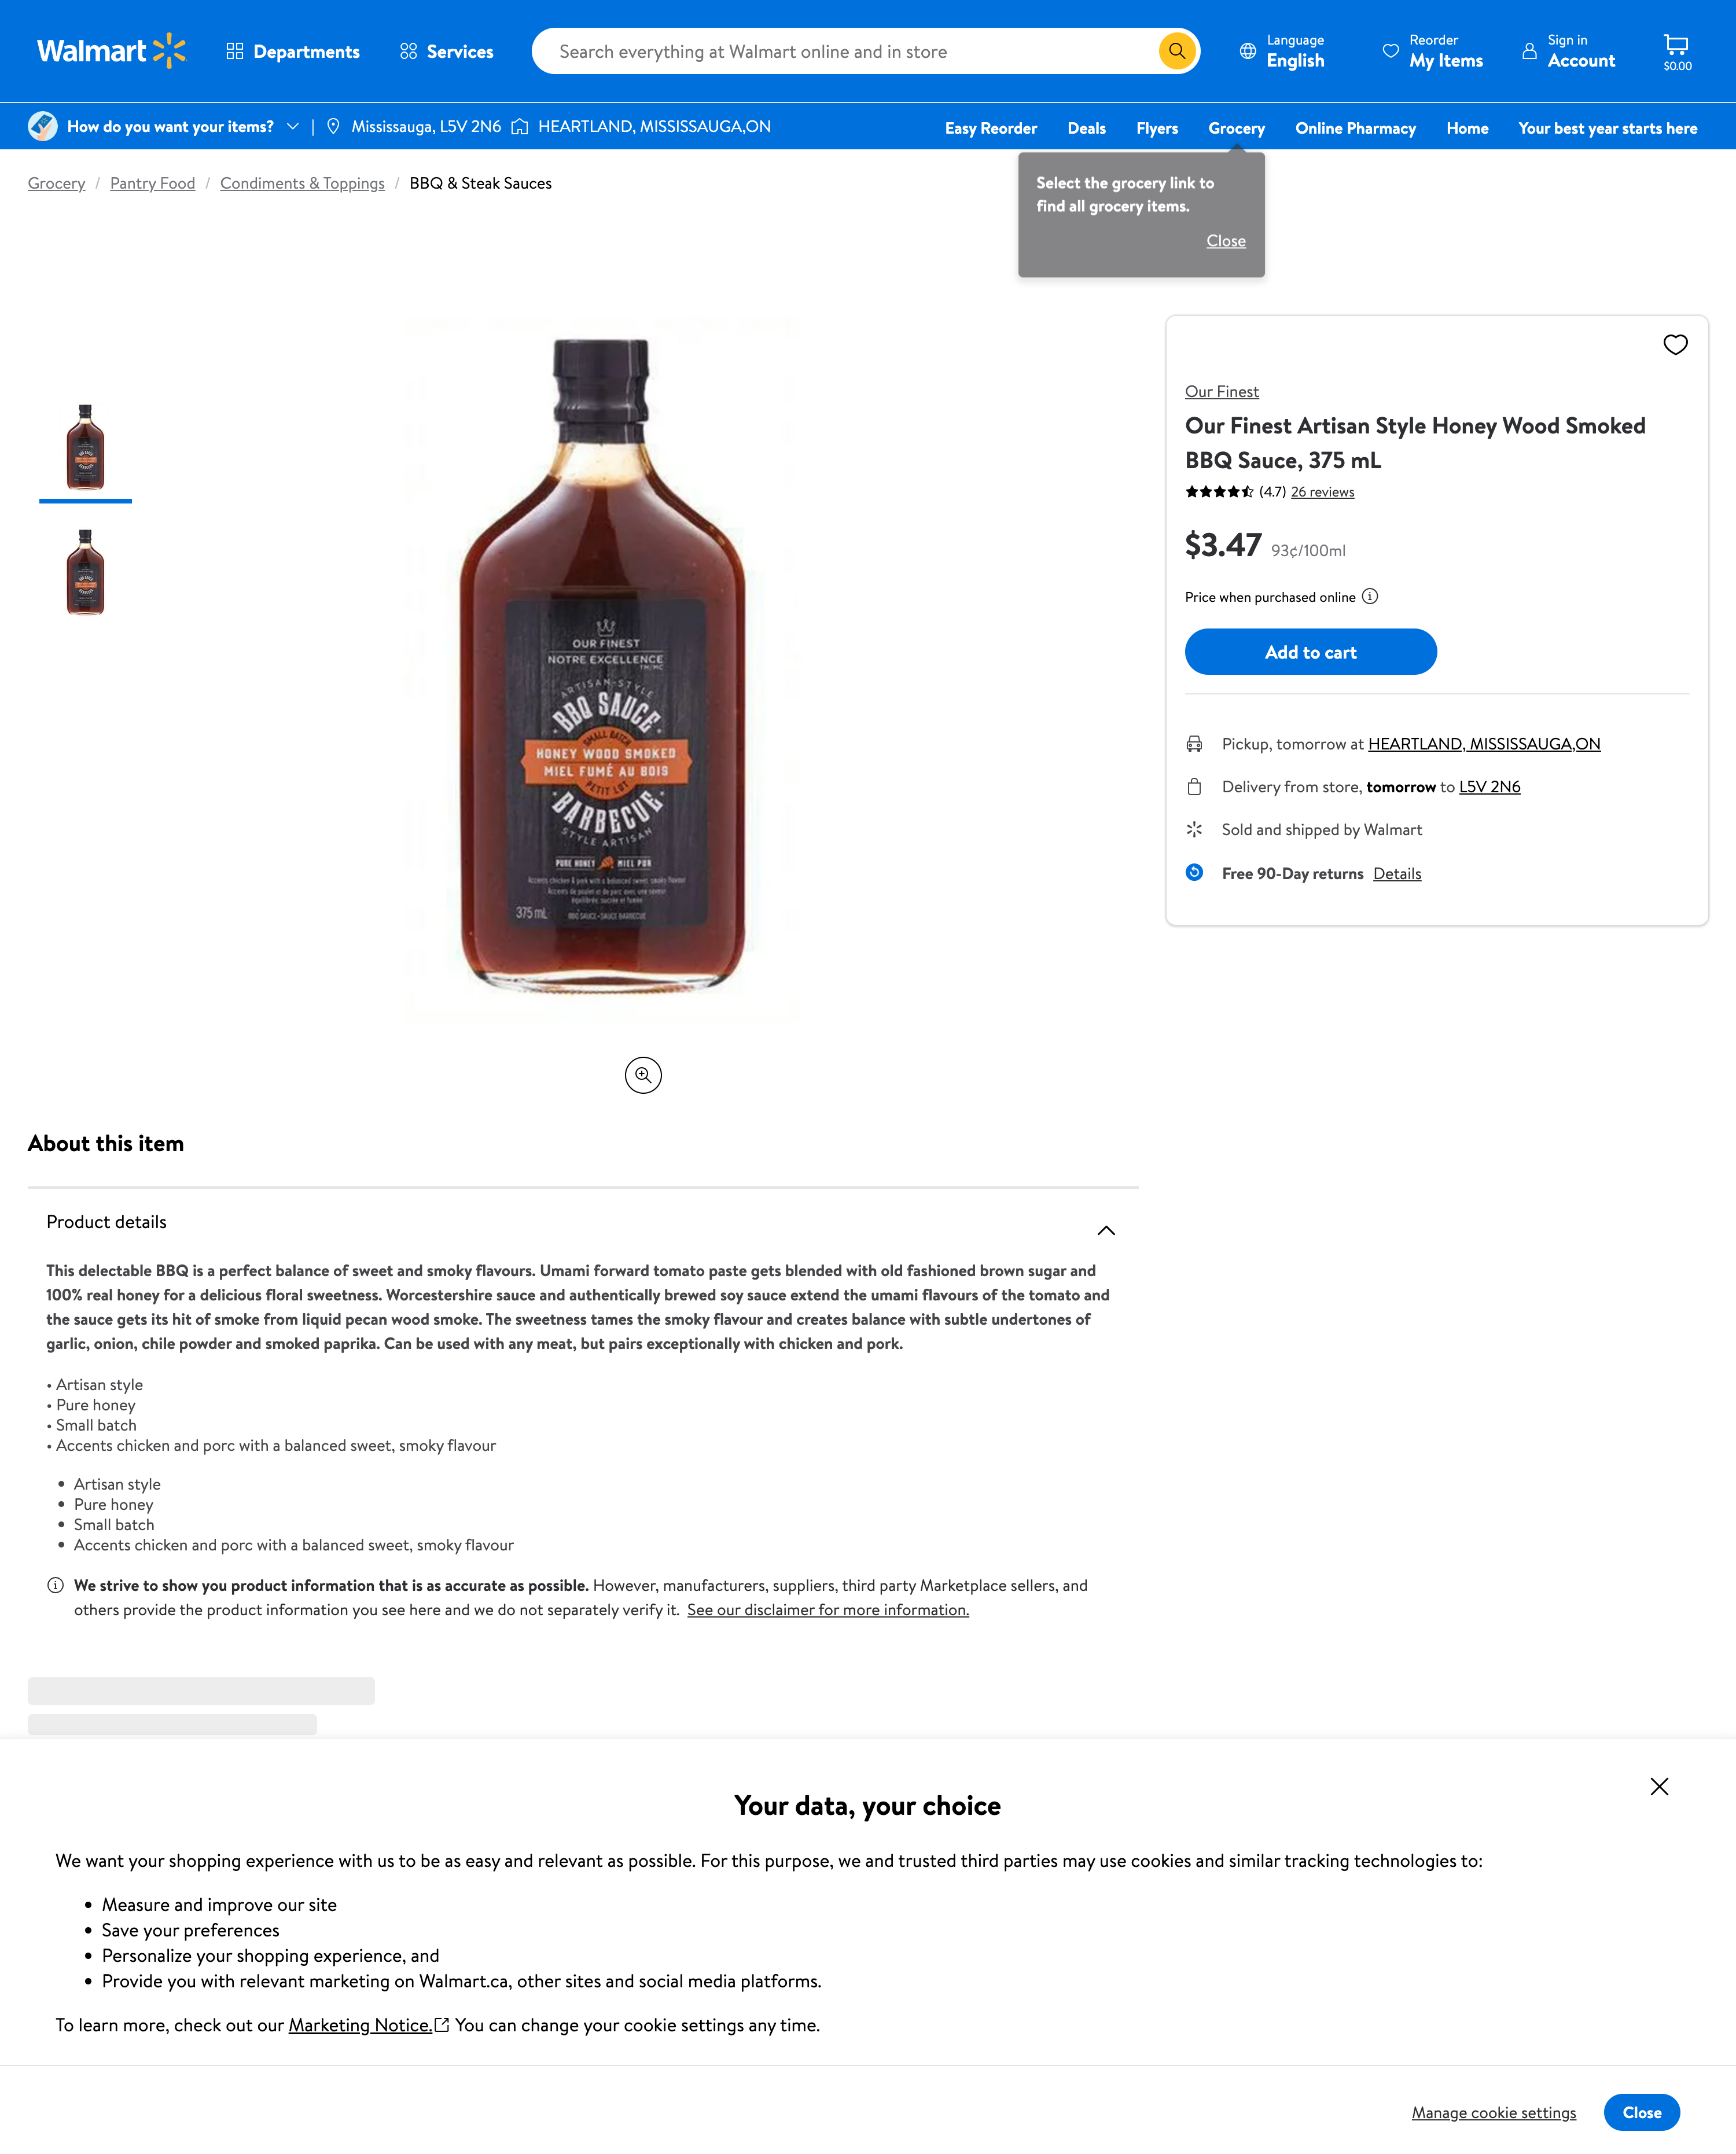

In [133]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from webdriver_manager.chrome import ChromeDriverManager
import os
import random
from IPython.display import Image, display

# ua=UserAgent()
# hdr = {'User-Agent': ua.random,
#       'Accept': 'text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8',
#       'Accept-Charset': 'ISO-8859-1,utf-8;q=0.7,*;q=0.3',
#       'Accept-Encoding': 'none',
#       'Accept-Language': 'en-US,en;q=0.8',
#       'Connection': 'keep-alive'}

def take_screenshot(url, save_path):
    # Set up Chrome options
    chrome_options = Options()
    chrome_options.add_argument("--headless")
    chrome_options.add_argument("--window-size=1500x1000")
    # chrome_options.add_argument(f"user-agent={hdr['User-Agent']}")
    chrome_options.add_argument(f"user-agent='Mozilla/5.0 (Macintosh; Intel Mac OS X 10_10_1) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/39.0.2171.95 Safari/537.36'")


    # Initialize the Chrome driver
    driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=chrome_options)

    # Open the URL
    driver.get(url)

    # WebDriverWait(driver, 20).until(
    #     lambda d: d.execute_script("return document.readyState") == "complete"
    # )
    # Click in the middle of the screen to close any pop-ups
    # driver.execute_script("window.scrollTo(0, document.body.scrollHeight / 2);")
    # button[aria-label="Close Select the grocery link to find all grocery items."]
    # grocery_close_button = driver.find_element(By.CSS_SELECTOR, 'button.w_1o4q')
    # grocery_close_button.click()
    # section.sticky button[aria-label="Close dialogue"]
    # try:
    #     # close_button = driver.find_element(By.XPATH, '//section[contains(@class, "sticky")]//button[@aria-label="acceptAll button"]')
    #     shadow_host = driver.find_element(By.CSS_SELECTOR, 'section.sticky')
    #     shadow_root = driver.execute_script("return arguments[0].shadowRoot", shadow_host)
    #     close_button = shadow_root.find_element(By.CSS_SELECTOR, 'header button')
    #     close_button.click()
    # except Exception as e:
    #     print(f"Could not find or click the close button: {e}")

    # # Hide the div with attribute data-focus-lock-disabled="false"
    # driver.execute_script("""
    #     var elements = document.querySelectorAll('div[data-focus-lock-disabled="false"]');
    #     elements.forEach(function(element) {
    #         element.style.display = 'none';
    #     });
    # """)

    # Run JavaScript to hide all elements with class 'sticky' -- didn't work on seleium 
    # driver.execute_script("""
    #     var elements = document.querySelectorAll('section.sticky');
    #     elements.forEach(function(element) {
    #         element.style.display = 'none';
    #     });
    # """)

    # Create the screenshots directory if it doesn't exist
    if not os.path.exists('./screenshots'):
        os.makedirs('./screenshots')

    # Perform a mouse click in the middle of the view
    webdriver.ActionChains(driver).move_by_offset(750, 500).click().perform()

    # Set the window size to 1500x2000
    driver.set_window_size(1500, 2000)
    # Save the screenshot
    driver.save_screenshot(save_path)

    # Quit the driver
    driver.quit()

# Example usage
# take_screenshot("https://www.walmart.ca/en/ip/Kraft-Chicken-Rib-BBQ-Sauce-455-ml-Bottle/10217942", f'./screenshots/test1.png')
# Pick a random product from all extracted_products
random_product = random.choice(extracted_products)

# Use the product's URL to run take_screenshot
take_screenshot(random_product['url'], f'./screenshots/random_product.png')
# Display the screenshot
display(Image(filename='./screenshots/random_product.png', width=500))

^ after a while walmart didn't like my tests, and I wasn't able to close the cookies overlay which was blocking the screenshot I needed
(though i can open a real browser on the same ip with the copy paster user agent and it unblocks it here)

In [ ]:
# define scrapeInfo(product_name, reference_site="https://walmart.ca") function for a given pandas row

# return name, quantity, unitOfMeasure, price, pricePerWeight, referenceUrl with returned values

# for each row with referenceUrl null, lambda scrapeInfo using the name column to fill in columns name, quantity, unitOfMeasure, pricePerWeight, referenceUrl with returned values

# TL;DR:

Scraping is a lot of work, and requires human intervention to find a good comparable product. This is something an AI could help with, but it's a pretty extensive task. 

I started entering the values manually ...

But then decide to keep the prices from previous years. 

